In [ ]:
import os

import re
import math
import time
import random
from collections import Counter


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: Tesla T4


In [16]:
# Load datasets

train_path = r"/kaggle/input/datasets/bhuvanvishaljuturu/english-french/en_fr_train.csv"
val_path = r"/kaggle/input/datasets/bhuvanvishaljuturu/english-french/en_fr_val.csv"
test_path = r"/kaggle/input/datasets/bhuvanvishaljuturu/english-french/en_fr_test.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Ensure string types and clean trailing whitespaces
train_df['en'] = train_df['en'].astype(str).str.strip()
train_df['fr'] = train_df['fr'].astype(str).str.strip()
val_df['en'] = val_df['en'].astype(str).str.strip()
val_df['fr'] = val_df['fr'].astype(str).str.strip()
test_df['en'] = test_df['en'].astype(str).str.strip()
test_df['fr'] = test_df['fr'].astype(str).str.strip()
train_df.head()

,en,fr
0,"Thank you so much, Chris. And it's truly a gre...","Merci beaucoup, Chris. C'est vraiment un honne..."
1,"I have been blown away by this conference, and...",J'ai été très impressionné par cette conférenc...
2,"And I say that sincerely, partly because Put ...","Et je dis çà sincèrement, en autres parce que ..."
3,I flew on Air Force Two for eight years.,J'ai volé avec Air Force 2 pendant huit ans.
4,Now I have to take off my shoes or boots to ge...,"Et maintenant, je dois enlever mes chaussures ..."


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232825 entries, 0 to 232824
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   en      232825 non-null  object
 1   fr      232825 non-null  object
dtypes: object(2)
memory usage: 3.6+ MB


In [18]:
len(train_df), len(val_df), len(test_df)

(232825, 890, 8597)

---
##  Tokenization & Vocabulary Pipeline

### Tokenization Strategy
- We use a regex word-boundary tokenizer `\w+|[^\w\s]` that cleanly separates alphanumeric words from punctuation while retaining contractions (e.g. `it's`, `c'est`, `j'ai`).
- Texts are converted to lowercase for consistency.

### Special Tokens
- `<unk>` (Index 0): Out-of-vocabulary / rare words.
- `<pad>` (Index 1): Padding token for batch alignment.
- `<sos>` (Index 2): Start-of-sequence token.
- `<eos>` (Index 3): End-of-sequence token.

### Vocabulary Frequency Thresholding (`min_freq`)
Without frequency filtering, the vocabulary explodes to over 80,000 words (mostly typos, singleton tokens, and noise), causing massive memory consumption. We apply `min_freq=2` (or 3) to keep a healthy, computationally efficient vocabulary.

In [19]:
# Special token constants
UNK_TOKEN = "<unk>"
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

UNK_IDX = 0
PAD_IDX = 1
SOS_IDX = 2
EOS_IDX = 3

def tokenize(text, lower=True):
    """Splits text into word tokens and punctuation marks."""
    if lower:
        text = text.lower()
    return re.findall(r"\w+|[^\w\s]", text)

class Vocab:
    def __init__(self, name, min_freq=2, max_size=None):
        self.name = name
        self.min_freq = min_freq
        self.max_size = max_size
        self.special_tokens = [UNK_TOKEN, PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
        self.stoi = {tok: idx for idx, tok in enumerate(self.special_tokens)}
        self.itos = {idx: tok for idx, tok in enumerate(self.special_tokens)}

    def build_vocab(self, sentences):
        counter = Counter()
        for sentence in sentences:
            tokens = tokenize(sentence)
            counter.update(tokens)

        # Filter by min_freq
        sorted_tokens = [w for w, count in counter.most_common() if count >= self.min_freq]
        if self.max_size is not None:
            sorted_tokens = sorted_tokens[: self.max_size - len(self.special_tokens)]

        for token in sorted_tokens:
            if token not in self.stoi:
                idx = len(self.stoi)
                self.stoi[token] = idx
                self.itos[idx] = token

        print(f"Vocab [{self.name}]: {len(self.stoi):,} tokens "
              f"(pruned {len(counter) - len(sorted_tokens):,} rare tokens with freq < {self.min_freq})")

    def numericalize(self, tokens, add_sos=True, add_eos=True):
        ids = []
        if add_sos:
            ids.append(SOS_IDX)
        ids.extend([self.stoi.get(tok, UNK_IDX) for tok in tokens])
        if add_eos:
            ids.append(EOS_IDX)
        return ids

    def decode(self, ids, remove_special=True):
        tokens = []
        for i in ids:
            if isinstance(i, torch.Tensor):
                i = i.item()
            tok = self.itos.get(i, UNK_TOKEN)
            if remove_special and tok in (PAD_TOKEN, SOS_TOKEN, EOS_TOKEN):
                if tok == EOS_TOKEN:
                    break
                continue
            tokens.append(tok)
        return " ".join(tokens)

    def __len__(self):
        return len(self.stoi)

In [ ]:
en_vocab = Vocab("English", min_freq=2)
fr_vocab = Vocab("French", min_freq=2)

en_vocab.build_vocab(train_df['en'])
fr_vocab.build_vocab(train_df['fr'])

Vocab [English]: 35,212 tokens (pruned 18,062 rare tokens with freq < 2)
Vocab [French]: 45,266 tokens (pruned 27,166 rare tokens with freq < 2)



##  PyTorch Dataset & DataLoader



In [21]:
class TranslationDataset(Dataset):
    def __init__(self, df, src_vocab, trg_vocab):
        self.src_data = [
            src_vocab.numericalize(tokenize(text))
            for text in df['en']
        ]
        self.trg_data = [
            trg_vocab.numericalize(tokenize(text))
            for text in df['fr']
        ]

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        return self.src_data[idx], self.trg_data[idx]

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)

    src_tensors = [torch.tensor(x, dtype=torch.long) for x in src_batch]
    trg_tensors = [torch.tensor(x, dtype=torch.long) for x in trg_batch]

    # Pad sequences to max length in the batch with PAD_IDX
    src_padded = pad_sequence(src_tensors, batch_first=False, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_tensors, batch_first=False, padding_value=PAD_IDX)

    return src_padded, trg_padded

In [22]:
# Create Datasets and DataLoaders
BATCH_SIZE = 64

train_dataset = TranslationDataset(train_df, en_vocab, fr_vocab)
val_dataset = TranslationDataset(val_df, en_vocab, fr_vocab)
test_dataset = TranslationDataset(test_df, en_vocab, fr_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


##  Model Architecture: From-Scratch Encoder-Decoder


### Encoder
The Encoder maps the input token IDs to dense embeddings, then processes them sequentially through a multi-layer LSTM.
The final hidden state $h_T$ and cell state $c_T$ form the **context vector** passed to initialize the decoder.
\begin{align*}
(h_T^1, c_T^1) &= \text{EncoderLSTM}^1(e(x_T), (h_{T-1}^1, c_{T-1}^1))\\
(h_T^2, c_T^2) &= \text{EncoderLSTM}^2(h_T^1, (h_{T-1}^2, c_{T-1}^2))
\end{align*}
$$\text{Context Vector} = (h_T, c_T) = \text{Encoder}(x_1, x_2, \dots, x_T)$$

### Decoder
The Decoder takes one token at a time $y_{t-1}$, embeds it, and updates its hidden state conditioned on the previous state $(s_{t-1}, c_{t-1})$. It then projects the hidden representation to the target vocabulary space using a linear layer `fc_out`.

\begin{align*}
(s_T^1, c_T^1) = \text{DecoderLSTM}^1(d(y_T), (s_{T-1}^1, c_{T-1}^1))\\
(s_T^2, c_T^2) = \text{DecoderLSTM}^2(s_T^1, (s_{T-1}^2, c_{T-1}^2))
\end{align*}

$$\hat{y}_t = \text{Softmax}(\text{Linear}(s_T))$$


<img src="https://github.com/bentrevett/pytorch-seq2seq/raw/b3cd54c72cd6e4e63f672d334c795b4fe744ef92/assets/seq2seq4.png" width="600">

### Teacher Forcing
During training when when model is predicting the word we sometimes give actual previous target instead of its own prediction,this makes the learning faster. 

In [23]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, n_layers=2, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: [src_len, batch_size]
        embedded = self.dropout(self.embedding(src))  # [src_len, batch_size, emb_dim]
        outputs, (hidden, cell) = self.rnn(embedded)
        # outputs: [src_len, batch_size, hidden_dim]
        # hidden, cell: [n_layers, batch_size, hidden_dim]
        return hidden, cell

In [24]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, n_layers=2, dropout=0.5):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers, dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell):
        # input_token: [batch_size] -> unsqueeze to [1, batch_size]
        input_token = input_token.unsqueeze(0)
        embedded = self.dropout(self.embedding(input_token))  # [1, batch_size, emb_dim]

        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        # output: [1, batch_size, hidden_dim]

        prediction = self.fc_out(output.squeeze(0))  # [batch_size, output_dim]
        return prediction, hidden, cell

In [25]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hidden_dim == decoder.hidden_dim, "Encoder & Decoder hidden_dim must match!"
        assert encoder.n_layers == decoder.n_layers, "Encoder & Decoder n_layers must match!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: [src_len, batch_size]
        # trg: [trg_len, batch_size]
        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # Tensor to store decoder logits
        outputs = torch.zeros(trg_len - 1, batch_size, trg_vocab_size, device=self.device)

        # Encode source sequence into context vector
        hidden, cell = self.encoder(src)

        # Initial decoder input is <sos> token
        input_token = trg[0, :]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[t - 1] = output

            # Teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[t] if teacher_force else top1

        return outputs

In [26]:
# Model hyperparameters
INPUT_DIM = len(en_vocab)
OUTPUT_DIM = len(fr_vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, N_LAYERS, ENC_DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(encoder, decoder, device).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

f"The model has {count_parameters(model):,} trainable parameters"

'The model has 51,180,242 trainable parameters'

---
## 6. Training & Validation Pipeline

- **Loss Function:** `nn.CrossEntropyLoss(ignore_index=PAD_IDX)`. Cross-entropy loss ignores padding positions.
- **Optimizer:** Adam with standard learning rate `lr=0.001`.
- **Gradient Clipping:** Gradients are clipped to `1.0` to avoid exploding gradients in recurrent networks.
- **Checkpointing:** Weights yielding the lowest validation loss are saved to `subtask1_seq2seq_best.pt`.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, dataloader, optimizer, criterion, clip=1.0, teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0

    for i, (src, trg) in enumerate(dataloader):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()


        output = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)
        output_dim = output.shape[-1]

        output = output.view(-1, output_dim)
        trg_target = trg[1:].view(-1)

        loss = criterion(output, trg_target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

       

    return epoch_loss / len(dataloader)

def evaluate_loss(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            # Teacher forcing turned off (0.0) during evaluation
            output = model(src, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]

            output = output.view(-1, output_dim)
            trg_target = trg[1:].view(-1)

            loss = criterion(output, trg_target)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [28]:
N_EPOCHS = 5
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5
best_valid_loss = float("inf")
checkpoint_path = "subtask1_seq2seq_best.pt"

history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}

print(f"Starting training for {N_EPOCHS} epochs...")
for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, clip=CLIP, teacher_forcing_ratio=TEACHER_FORCING_RATIO
    )
    val_loss = evaluate_loss(model, val_loader, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    train_ppl = math.exp(min(train_loss, 100))
    val_ppl = math.exp(min(val_loss, 100))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)

    if val_loss < best_valid_loss:
        best_valid_loss = val_loss
        torch.save(model.state_dict(), checkpoint_path)
        save_msg = f"[*] Saved checkpoint to {checkpoint_path}"
    else:
        save_msg = ""

    print(f"Epoch: {epoch+1:02d} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"  Train Loss: {train_loss:.4f} | Train PPL: {train_ppl:.2f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val PPL:   {val_ppl:.2f} {save_msg}")

Starting training for 5 epochs...
Epoch: 01 | Time: 73m 19s
  Train Loss: 5.5348 | Train PPL: 253.36
  Val Loss:   5.9929 | Val PPL:   400.59 [*] Saved checkpoint to subtask1_seq2seq_best.pt
Epoch: 02 | Time: 73m 38s
  Train Loss: 4.9094 | Train PPL: 135.56
  Val Loss:   5.8802 | Val PPL:   357.90 [*] Saved checkpoint to subtask1_seq2seq_best.pt
Epoch: 03 | Time: 73m 43s
  Train Loss: 4.6764 | Train PPL: 107.38
  Val Loss:   5.7628 | Val PPL:   318.24 [*] Saved checkpoint to subtask1_seq2seq_best.pt
Epoch: 04 | Time: 73m 39s
  Train Loss: 4.5102 | Train PPL: 90.94
  Val Loss:   5.7253 | Val PPL:   306.52 [*] Saved checkpoint to subtask1_seq2seq_best.pt
Epoch: 05 | Time: 73m 47s
  Train Loss: 4.3879 | Train PPL: 80.47
  Val Loss:   5.6740 | Val PPL:   291.21 [*] Saved checkpoint to subtask1_seq2seq_best.pt


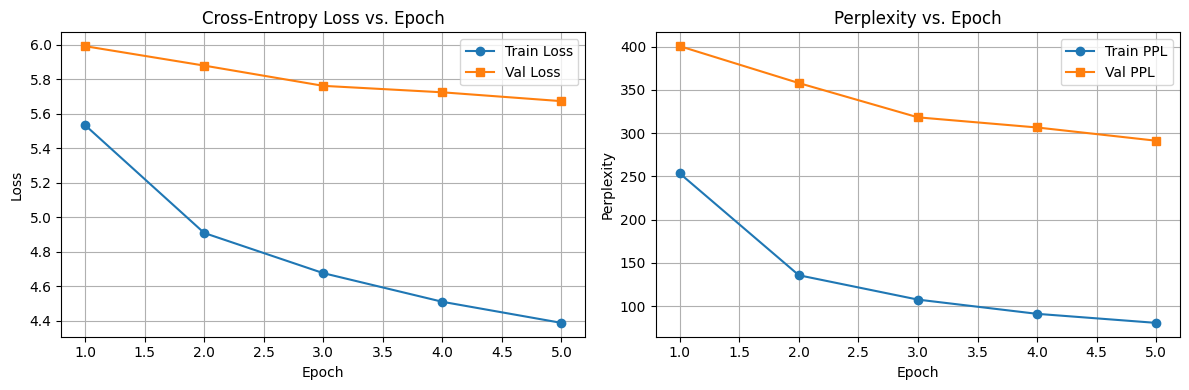

In [37]:
# Plot loss and perplexity learning curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], label="Train Loss", marker='o')
plt.plot(range(1, len(history["val_loss"]) + 1), history["val_loss"], label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss vs. Epoch")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history["train_ppl"]) + 1), history["train_ppl"], label="Train PPL", marker='o')
plt.plot(range(1, len(history["val_ppl"]) + 1), history["val_ppl"], label="Val PPL", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity vs. Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## 7. Autoregressive Inference 

In [ ]:
# Load best checkpoint for inference & evaluation
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded best model weights from {checkpoint_path}")

def translate_sentence(sentence, model, src_vocab, trg_vocab, device, max_len=50):
    """
    Translates an English sentence into French using greedy autoregressive decoding.
    """
    model.eval()

    if isinstance(sentence, str):
        tokens = tokenize(sentence)
    else:
        tokens = sentence

    src_ids = src_vocab.numericalize(tokens, add_sos=True, add_eos=True)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(1)  # [src_len, 1]

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    trg_ids = [SOS_IDX]

    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_ids[-1]], dtype=torch.long, device=device)
        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)

        pred_token = output.argmax(1).item()
        trg_ids.append(pred_token)

        if pred_token == EOS_IDX:
            break

    pred_tokens = [
        trg_vocab.itos.get(idx, UNK_TOKEN)
        for idx in trg_ids
        if idx not in (SOS_IDX, EOS_IDX)]
    pred_sentence = " ".join(pred_tokens)
    return pred_tokens, pred_sentence

Loaded best model weights from subtask1_seq2seq_best.pt


## EVALUATION WITH BLEU SCORE

In [40]:
def calculate_bleu(model, test_dataframe, src_vocab, trg_vocab, device, max_samples=1000):
    """
    Computes corpus-level BLEU scores across the held-out test split.
    """
    model.eval()
    eval_df = test_dataframe.iloc[:max_samples] if max_samples else test_dataframe

    references = []
    hypotheses = []
    smoother = SmoothingFunction().method1

    start_t = time.time()
    for idx, row in eval_df.iterrows():
        src_text = row['en']
        ref_text = row['fr']

        ref_tokens = tokenize(ref_text)
        pred_tokens, _ = translate_sentence(src_text, model, src_vocab, trg_vocab, device)

        references.append([ref_tokens])
        hypotheses.append(pred_tokens)

    total_time = time.time() - start_t

    b1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0), smoothing_function=smoother) * 100
    b2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother) * 100
    b3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.34, 0), smoothing_function=smoother) * 100
    b4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother) * 100

    print(f"\nTest Set BLEU Evaluation ({len(eval_df):,} examples evaluated in {total_time:.1f}s):")
    print("+" + "-"*20 + "+" + "-"*15 + "+")
    print(f"| {'Metric':<18} | {'Score (%)':<13} |")
    print("+" + "-"*20 + "+" + "-"*15 + "+")
    print(f"| {'BLEU-1':<18} | {b1:<13.2f} |")
    print(f"| {'BLEU-2':<18} | {b2:<13.2f} |")
    print(f"| {'BLEU-3':<18} | {b3:<13.2f} |")
    print(f"| {'BLEU-4 (Cumulative)':<18} | {b4:<13.2f} |")
    print("+" + "-"*20 + "+" + "-"*15 + "+")

    return {"bleu_1": b1, "bleu_2": b2, "bleu_3": b3, "bleu_4": b4, "hypotheses": hypotheses, "references": references}

In [41]:
# Evaluate BLEU on the test split (evaluating first 1,000 samples for swift scoring; set max_samples=None for all 8,597)
bleu_results = calculate_bleu(model, test_df, en_vocab, fr_vocab, device, max_samples=1000)


Test Set BLEU Evaluation (1,000 examples evaluated in 18.5s):
+--------------------+---------------+
| Metric             | Score (%)     |
+--------------------+---------------+
| BLEU-1             | 31.56         |
| BLEU-2             | 16.19         |
| BLEU-3             | 9.51          |
| BLEU-4 (Cumulative) | 5.94          |
+--------------------+---------------+


In [42]:
# Vocabulary statistics
print(f"English vocab size: {len(en_vocab)}")
print(f"French vocab size:  {len(fr_vocab)}")
print(f"UNK index: {UNK_IDX}")
print(f"PAD index: {PAD_IDX}")
print(f"SOS index: {SOS_IDX}")
print(f"EOS index: {EOS_IDX}")

English vocab size: 35212
French vocab size:  45266
UNK index: 0
PAD index: 1
SOS index: 2
EOS index: 3


## FAILURE MODE ANALYSIS


In [43]:
# BLEU-4 by sentence length bucket
# Demonstrates the information bottleneck degradation on longer sentences

smoother = SmoothingFunction().method1

length_buckets = {"Short (<=10 words)": [], "Medium (11-25 words)": [], "Long (>25 words)": []}
bucket_refs = {"Short (<=10 words)": [], "Medium (11-25 words)": [], "Long (>25 words)": []}

eval_subset = test_df.iloc[:500]
for _, row in eval_subset.iterrows():
    src_text = row['en']
    ref_text = row['fr']
    src_tokens = tokenize(src_text)
    n_words = len(src_tokens)

    ref_tokens = tokenize(ref_text)
    pred_tokens, _ = translate_sentence(src_text, model, en_vocab, fr_vocab, device)

    if n_words <= 10:
        bucket = "Short (<=10 words)"
    elif n_words <= 25:
        bucket = "Medium (11-25 words)"
    else:
        bucket = "Long (>25 words)"

    length_buckets[bucket].append(pred_tokens)
    bucket_refs[bucket].append([ref_tokens])

print("BLEU-4 by Source Sentence Length:")
print("+" + "-"*25 + "+" + "-"*12 + "+" + "-"*10 + "+")
print(f"| {'Bucket':<23} | {'BLEU-4 (%)':<10} | {'Count':<8} |")
print("+" + "-"*25 + "+" + "-"*12 + "+" + "-"*10 + "+")
for bucket_name in ["Short (<=10 words)", "Medium (11-25 words)", "Long (>25 words)"]:
    if len(bucket_refs[bucket_name]) > 0:
        b4 = corpus_bleu(bucket_refs[bucket_name], length_buckets[bucket_name],
                         weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother) * 100
    else:
        b4 = 0.0
    print(f"| {bucket_name:<23} | {b4:<10.2f} | {len(length_buckets[bucket_name]):<8} |")
print("+" + "-"*25 + "+" + "-"*12 + "+" + "-"*10 + "+")

BLEU-4 by Source Sentence Length:
+-------------------------+------------+----------+
| Bucket                  | BLEU-4 (%) | Count    |
+-------------------------+------------+----------+
| Short (<=10 words)      | 8.51       | 124      |
| Medium (11-25 words)    | 6.36       | 266      |
| Long (>25 words)        | 4.18       | 110      |
+-------------------------+------------+----------+


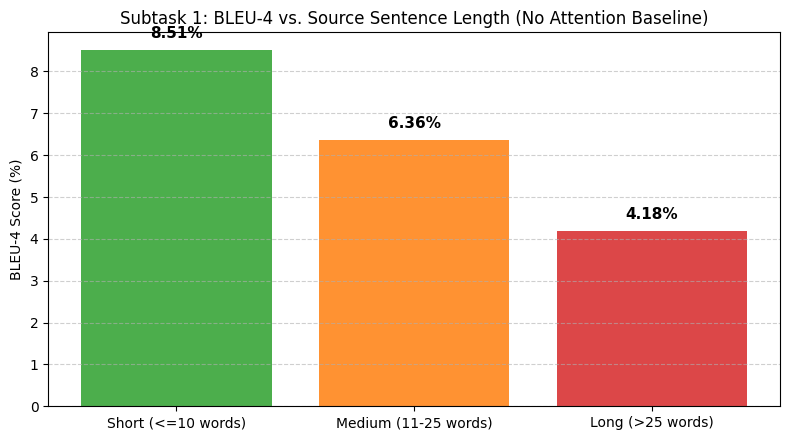

In [44]:
# Visualize BLEU-4 degradation across sentence lengths
bucket_names = list(length_buckets.keys())
bleu_scores = []
for bn in bucket_names:
    if len(bucket_refs[bn]) > 0:
        b4 = corpus_bleu(bucket_refs[bn], length_buckets[bn],
                         weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother) * 100
    else:
        b4 = 0.0
    bleu_scores.append(b4)

plt.figure(figsize=(8, 4.5))
bars = plt.bar(bucket_names, bleu_scores, color=['#2ca02c', '#ff7f0e', '#d62728'], alpha=0.85)
for bar, score in zip(bars, bleu_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{score:.2f}%", ha='center', fontweight='bold', fontsize=11)
plt.ylabel("BLEU-4 Score (%)")
plt.title("Subtask 1: BLEU-4 vs. Source Sentence Length (No Attention Baseline)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

From the barplot we can observe that the BLUE-4 score decreases with number of words in each sentance.This is primarly because of information bottleneck in the encoder-decoder architecture.

In our encoder-decoder architecture,the encoder process the entire input sentence and compresses to fixed dimensional hidden state,so regardless of length of sentence the decoder must rely on this fixed size vector.For shorter sentences this representation can retain of information but as length increases the information in the sentances increases(can include grammatic relationships,word meanings),some of this information maybe lost or difficult for decoder to translate

This limitation can be treated by using attention mechanism over basic encoder-decoder as they allow decoder to access different encoder hidden states dynamically instead of relying on single context vector

## REFERENCES

[**Sequence to Sequence Learning with Neural Networks**](https://arxiv.org/abs/1409.3215)
